In [ ]:
# Cell 0: Install dependencies
!pip install transformers torch sentencepiece datasets -q


In [ ]:
# Cell 1: Imports
import torch
from transformers import AutoTokenizer, pipeline
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
import re
from tqdm import tqdm
from functools import lru_cache
import warnings
import unicodedata
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

✓ Libraries imported


In [ ]:
# Cell 2: HuggingFace Login (Kaggle version — from Secrets)
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("✓ HuggingFace logged in via Kaggle Secret")

# Note: load_dataset call removed — we use pre-computed pickle instead (see Cell 9).


✓ HuggingFace logged in via Kaggle Secret


In [ ]:
# Cell 3: Configuration — 15 pairs, 8 train / 7 zero-shot
# All 15 language pairs in SwitchLingua
ALL_LANGUAGE_PAIRS = [
    ("Cantonese", "English"),   # 119248 samples
    ("Arabic", "English"),      # 8548
    ("Philippines", "English"),  # 8537
    ("German", "French"),       # 8511
    ("Chinese", "English"),     # 8458
    ("Vietnamese", "English"),  # 8457
    ("Malay", "English"),       # 8386
    ("Japanese", "English"),    # 8385
    ("Hindi", "English"),       # 8381
    ("Korean", "English"),      # 8266
    ("Spanish", "English"),     # 8110
    ("French", "English"),      # 8070
    ("Russian", "English"),     # 8017
    ("Italian", "English"),     # 7979
    ("German", "English"),      # 6819
]

# ── Train pairs (8): max linguistic diversity ──────────────────────────────
# Chinese-EN:     Sino-Tibetan, logographic (CJK)
# Hindi-EN:       Indo-European / Indo-Aryan, Devanagari script
# Italian-EN:     Indo-European / Romance, Latin script
# German-EN:      Indo-European / Germanic, Latin script
# Arabic-EN:      Afro-Asiatic, Arabic script (RTL)
# Japanese-EN:    Japonic, mixed script (hiragana/katakana/kanji)
# Vietnamese-EN:  Austroasiatic, Latin script with tonal diacritics
# Spanish-EN:     Indo-European / Romance, Latin script (high CS frequency)

TRAIN_PAIRS = [
    ("Chinese", "English"),
    ("Hindi", "English"),
    ("Italian", "English"),
    ("German", "English"),
    ("Arabic", "English"),
    ("Japanese", "English"),
    ("Vietnamese", "English"),
    ("Spanish", "English"),
]

# ── Zero-shot pairs (7): test generalization ──────────────────────────────
# Korean-EN:      unseen script (Hangul), unseen language family
# Russian-EN:     unseen script (Cyrillic), Indo-European / Slavic
# French-EN:      same family as Italian+Spanish (Romance) — tests within-family transfer
# Malay-EN:       unseen family (Austronesian), Latin script
# Filipino-EN:    unseen family (Austronesian), Latin script — double-checks Malay transfer
# German-French:  only non-English pair — hardest generalization test
# Cantonese-EN:   same script as Chinese-EN — tests Chinese→Cantonese transfer
#                 (not natively supported by XLM-R or mBERT, shares Unicode with Chinese)

ZEROSHOT_PAIRS = [
    ("Korean", "English"),
    ("Russian", "English"),
    ("French", "English"),
    ("Malay", "English"),
    ("Philipines", "English"),   # Filipino
    ("German", "French"),
    ("Cantonese", "English"),
]

CONFIG = {
    'model_name': 'xlm-roberta-base',
    'lid_model': 'papluca/xlm-roberta-base-language-detection',
    'max_samples_per_pair': 6000,
    'device': 0 if torch.cuda.is_available() else -1,
}

print(f"Device: {'GPU' if CONFIG['device'] == 0 else 'CPU'}")
print(f"All language pairs: {len(ALL_LANGUAGE_PAIRS)}")
print(f"Train pairs: {len(TRAIN_PAIRS)}")
print(f"Zero-shot pairs: {len(ZEROSHOT_PAIRS)}")

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f"✓ Tokenizer loaded: {CONFIG['model_name']}  |  vocab size: {tokenizer.vocab_size:,}")

Device: GPU
All language pairs: 15
Train pairs: 8
Zero-shot pairs: 7


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Tokenizer loaded: xlm-roberta-base  |  vocab size: 250,002


In [ ]:
# Cell 4: Production-Grade LID System
# Kaggle: SKIPPED — pre-computed pickle is loaded in Cell 9 below.
# Original code preserved below for reference / re-running if ever needed.
if False:
    def is_language_neutral_content(text: str) -> bool:
        if not text or not text.strip():
            return True
        return not any(unicodedata.category(c).startswith('L') for c in text.strip())


    class ProductionLID:
        def __init__(self, model_name: str = "papluca/xlm-roberta-base-language-detection"):
            print("Loading Transformer-based LID model...")
            self.device = 0 if torch.cuda.is_available() else -1
            self.lid_model = pipeline(
                "text-classification",
                model=model_name,
                device=self.device,
                batch_size=32,
            )

            self.lang_map = {
                'en': 'English',  'zh': 'Chinese', 'ja': 'Japanese',
                'ar': 'Arabic',   'hi': 'Hindi',   'vi': 'Vietnamese',
                'ru': 'Russian',  'fr': 'French',  'de': 'German',
                'es': 'Spanish',  'it': 'Italian', 'ko': 'Korean',
                'ms': 'Malay',    'tl': 'Filipino',
            }

            self.unicode_ranges = {
                'Japanese': [(0x3040, 0x309F), (0x30A0, 0x30FF)],
                'Korean':   [(0xAC00, 0xD7AF)],
                'Arabic':   [(0x0600, 0x06FF)],
                'Hindi':    [(0x0900, 0x097F)],
                'Russian':  [(0x0400, 0x04FF)],
                'Chinese':  [(0x4E00, 0x9FFF), (0x3400, 0x4DBF)],
            }

            self.lexicons = {
                'Vietnamese': frozenset([
                    'có', 'là', 'không', 'và', 'của', 'cho', 'trong', 'với', 'được', 'này',
                    'các', 'một', 'những', 'khi', 'nhưng', 'hay', 'để', 'từ', 'đã', 'cũng',
                    'phải', 'sẽ', 'nếu', 'vì', 'hoặc', 'đến', 'ra', 'về', 'năm', 'người',
                ]),
                'Cantonese': frozenset([
                    '嘅', '咗', '唔', '係', '喺', '咁', '哋', '嚟', '噉', '嘢', '啲', '咩',
                    '冇', '佢', '乜', '嗰', '吖', '嘞', '噃', '啩', '咯', '㗎',
                ]),
                'German': frozenset([
                    'ich', 'nicht', 'ist', 'das', 'die', 'der', 'und', 'ein', 'zu', 'mit',
                    'sich', 'auf', 'auch', 'dass', 'aber', 'noch', 'wird', 'beim', 'vom',
                    'haben', 'sein', 'war', 'sind', 'wurde', 'wenn', 'durch', 'nach', 'oder',
                ]),
                'French': frozenset([
                    'je', 'ne', 'pas', 'est', 'les', 'des', 'une', 'que', 'qui', 'dans',
                    'avec', 'sur', 'pour', 'par', 'mais', 'ont', 'être', 'très', 'bien',
                    'nous', 'vous', 'ils', 'elle', 'tout', 'plus', 'cette', 'comme', 'aux',
                ]),
                'Malay': frozenset([
                    'dan', 'yang', 'ini', 'itu', 'di', 'dengan', 'untuk', 'tidak', 'ada',
                    'dari', 'dalam', 'akan', 'pada', 'juga', 'saya', 'sudah', 'bisa',
                    'mereka', 'seperti', 'tetapi', 'atau', 'hanya', 'oleh', 'karena',
                ]),
                'Filipino': frozenset([
                    'ang', 'mga', 'sa', 'na', 'ng', 'ko', 'ka', 'niya', 'siya', 'ito',
                    'ako', 'mo', 'namin', 'nila', 'pero', 'kasi', 'talaga', 'lang',
                    'din', 'dito', 'yung', 'parang', 'dapat', 'pwede', 'gusto',
                ]),
                'Korean': frozenset([
                    '이', '그', '저', '것', '수', '등', '들', '및', '을', '를',
                    '에', '의', '가', '으로', '하다', '있다', '되다', '없다',
                ]),
                'Spanish': frozenset([
                    'el', 'la', 'los', 'las', 'un', 'una', 'que', 'en', 'es', 'por',
                    'con', 'para', 'como', 'pero', 'más', 'este', 'ya', 'todo', 'esta',
                    'ser', 'también', 'fue', 'había', 'muy', 'puede', 'todos', 'así',
                    'nos', 'cuando', 'algo', 'entre', 'sin', 'sobre', 'tiene', 'donde',
                ]),
            }

            self.ngram_features = {
                'Vietnamese': frozenset('àáâãèéêìíòóôõùúýăđơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵỷỹ'),
                'German':     frozenset('äöüßÄÖÜ'),
                'French':     frozenset('çœæÇŒÆ'),
                'Spanish':    frozenset('ñ¿¡Ñ'),
            }

            self._word_cache: dict[str, str] = {}
            print(f"✓ LID model loaded on {'GPU' if self.device >= 0 else 'CPU'}")

        def _unicode_check(self, text: str) -> str | None:
            for ch in text:
                cp = ord(ch)
                for lang, ranges in self.unicode_ranges.items():
                    for lo, hi in ranges:
                        if lo <= cp <= hi:
                            return lang
            return None

        def _ngram_check(self, text: str, lang1: str, lang2: str) -> str | None:
            for lang, char_set in self.ngram_features.items():
                if lang not in (lang1, lang2):
                    continue
                if any(c in char_set for c in text):
                    return lang
            return None

        def _transformer_detect_single(self, text: str, lang1: str, lang2: str) -> str:
            try:
                results = self.lid_model(text, top_k=3)
                for r in results:
                    label = r['label']
                    detected = self.lang_map.get(label)
                    if label == 'zh':
                        detected = 'Cantonese' if 'Cantonese' in (lang1, lang2) else 'Chinese'
                    if detected in (lang1, lang2):
                        return detected
            except Exception:
                pass
            return lang1

        def _batch_transformer_detect(self, texts: list[str],
                                       lang1: str, lang2: str) -> list[str]:
            if not texts:
                return []
            unique = list(dict.fromkeys(texts))
            result_map: dict[str, str] = {}
            try:
                batch_results = self.lid_model(unique, top_k=3, batch_size=32)
                for word, top3 in zip(unique, batch_results):
                    resolved = lang1
                    for r in top3:
                        label = r['label']
                        detected = self.lang_map.get(label)
                        if label == 'zh':
                            detected = 'Cantonese' if 'Cantonese' in (lang1, lang2) else 'Chinese'
                        if detected in (lang1, lang2):
                            resolved = detected
                            break
                    result_map[word] = resolved
            except Exception:
                result_map = {w: lang1 for w in unique}
            return [result_map[t] for t in texts]

        def detect_language(self, text: str, lang1: str, lang2: str) -> str:
            clean = re.sub(r'[^\w\s]', '', text).strip()
            if not clean or is_language_neutral_content(clean):
                return 'neutral'
            hit = self._unicode_check(clean)
            if hit and hit in (lang1, lang2):
                return hit
            word_lower = clean.lower().split()[0]
            for lang, lexicon in self.lexicons.items():
                if lang not in (lang1, lang2):
                    continue
                if word_lower in lexicon or any(c in lexicon for c in clean):
                    return lang
            hit = self._ngram_check(clean, lang1, lang2)
            if hit:
                return hit
            cached = self._word_cache.get(clean)
            if cached is not None:
                return cached
            result = self._transformer_detect_single(clean, lang1, lang2)
            self._cache_set(clean, result)
            return result

        def word_level_lid(self, text: str, lang1: str, lang2: str
                           ) -> Tuple[List[str], List[str]]:
            words = text.split()
            lids: list[str | None] = []
            l4_positions: list[int] = []
            l4_texts: list[str] = []

            for i, word in enumerate(words):
                clean = re.sub(r'[^\w]', '', word)
                if not clean or is_language_neutral_content(clean):
                    lids.append('neutral')
                    continue
                hit = self._unicode_check(clean)
                if hit and hit in (lang1, lang2):
                    lids.append(hit)
                    continue
                hit_lang = None
                word_lower = clean.lower()
                for lang, lexicon in self.lexicons.items():
                    if lang not in (lang1, lang2):
                        continue
                    if word_lower in lexicon or any(c in lexicon for c in clean):
                        hit_lang = lang
                        break
                if hit_lang:
                    lids.append(hit_lang)
                    continue
                hit = self._ngram_check(clean, lang1, lang2)
                if hit:
                    lids.append(hit)
                    continue
                cached = self._word_cache.get(clean)
                if cached is not None:
                    lids.append(cached)
                    continue
                lids.append(None)
                l4_positions.append(i)
                l4_texts.append(clean)

            if l4_texts:
                detected = self._batch_transformer_detect(l4_texts, lang1, lang2)
                for pos, lang, clean in zip(l4_positions, detected, l4_texts):
                    lids[pos] = lang
                    self._cache_set(clean, lang)

            lids = [l if l is not None else lang1 for l in lids]
            return words, lids

        def _cache_set(self, text: str, lang: str) -> None:
            if len(self._word_cache) >= 100_000:
                self._word_cache.clear()
            self._word_cache[text] = lang


    print("Initializing Production LID System...")
    production_lid = ProductionLID()
    print("✓ LID System Ready\n")
print("↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)")


↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)


In [ ]:
# Cell 5: Subword alignment + Label generation
# Kaggle: SKIPPED — pre-computed pickle is loaded in Cell 9 below.
# Original code preserved below for reference / re-running if ever needed.
if False:
    def align_subwords_to_words(words: List[str],
                                 word_lids: List[str]) -> Tuple[List[str], List[str]]:
        assert len(words) == len(word_lids), (
            f"Length mismatch: {len(words)} words vs {len(word_lids)} lids"
        )
        tokens, token_lids = [], []
        for word, lid in zip(words, word_lids):
            word_tokens = tokenizer.tokenize(word)
            if not word_tokens:
                continue
            for token in word_tokens:
                clean_token = token.replace('▁', '').strip()
                if not clean_token or is_language_neutral_content(clean_token):
                    tokens.append(token)
                    token_lids.append('neutral')
                else:
                    tokens.append(token)
                    token_lids.append(lid)
        return tokens, token_lids


    def generate_labels(token_lids: List[str]) -> Tuple[List[int], List[int]]:
        n = len(token_lids)
        if n < 2:
            return [], []

        next_nn: List[int | None] = [None] * n
        last_nn = None
        for i in range(n - 1, -1, -1):
            if token_lids[i] != 'neutral':
                last_nn = i
            next_nn[i] = last_nn

        y_switch   = []
        y_duration = []

        for t in range(n - 1):
            current_lid = token_lids[t]
            if current_lid == 'neutral':
                y_switch.append(0)
                y_duration.append(-1)
                continue

            next_pos = next_nn[t + 1] if t + 1 < n else None
            if next_pos is None:
                y_switch.append(0)
                y_duration.append(-1)
                continue

            next_lid  = token_lids[next_pos]
            is_switch = current_lid != next_lid
            y_switch.append(1 if is_switch else 0)

            if is_switch:
                burst_len = 1
                for i in range(next_pos + 1, n):
                    if token_lids[i] == 'neutral':
                        continue
                    if token_lids[i] == next_lid:
                        burst_len += 1
                    else:
                        break
                if burst_len <= 2:
                    y_duration.append(0)
                elif burst_len <= 6:
                    y_duration.append(1)
                else:
                    y_duration.append(2)
            else:
                y_duration.append(-1)

        return y_switch, y_duration
print("↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)")


↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)


In [ ]:
# Cell 6: Sample processing + Language-pair analysis (unchanged)
# Kaggle: SKIPPED — pre-computed pickle is loaded in Cell 9 below.
# Original code preserved below for reference / re-running if ever needed.
if False:
    def process_sample(sample: dict, lang1: str, lang2: str) -> dict | None:
        raw = sample.get('data_generation_result', '')
        if isinstance(raw, list):
            text = ' '.join(str(s) for s in raw if s)
        else:
            text = raw if isinstance(raw, str) else ''
        if not text or not text.strip():
            return None
        try:
            words, word_lids = production_lid.word_level_lid(text, lang1, lang2)
            tokens, token_lids = align_subwords_to_words(words, word_lids)
            if len(tokens) < 2:
                return None
            y_switch, y_duration = generate_labels(token_lids)
            return {
                'text':       text,
                'tokens':     tokens,
                'token_lids': token_lids,
                'y_switch':   y_switch,
                'y_duration': y_duration,
                'cs_type':    sample.get('cs_type',     'unknown'),
                'cs_function':sample.get('cs_function', 'unknown'),
            }
        except Exception as e:
            print(f"[process_sample] {lang1}-{lang2} | error: {type(e).__name__}: {e}")
            return None


    def analyze_language_pair(dataset_split, lang1: str, lang2: str,
                               max_samples: int = 6000) -> dict | None:
        print(f"\n{'='*70}")
        print(f"Processing: {lang1} - {lang2}")
        print(f"{'='*70}")

        filtered_data = dataset_split.filter(
            lambda x: (x.get('first_language') == lang1 and x.get('second_language') == lang2) or
                      (x.get('first_language') == lang2 and x.get('second_language') == lang1)
        )

        print(f"Found {len(filtered_data)} samples")
        if len(filtered_data) == 0:
            print("No samples found, skipping...")
            return None

        sample_size   = min(len(filtered_data), max_samples)
        filtered_data = filtered_data.select(range(sample_size))

        stats = {
            'lang_pair':              f"{lang1}-{lang2}",
            'total_samples':          0,
            'total_tokens':           0,
            'total_switches':         0,
            'duration_distribution':  Counter(),
            'cs_type_distribution':   Counter(),
            'switch_rate_per_sample': [],
            'processed_samples':      [],
        }

        print(f"Processing {sample_size} samples...")
        for idx in tqdm(range(sample_size), desc=f"  {lang1}-{lang2}"):
            result = process_sample(filtered_data[idx], lang1, lang2)
            if result is None:
                continue

            stats['total_samples']  += 1
            stats['total_tokens']   += len(result['tokens'])
            stats['total_switches'] += sum(result['y_switch'])

            for dur in result['y_duration']:
                if dur != -1:
                    stats['duration_distribution'][dur] += 1

            stats['cs_type_distribution'][result['cs_type']] += 1

            if result['tokens']:
                stats['switch_rate_per_sample'].append(
                    sum(result['y_switch']) / len(result['tokens'])
                )

            stats['processed_samples'].append(result)

        failed = sample_size - stats['total_samples']
        print(f"✓ Processed: {stats['total_samples']:,}  |  Failed: {failed}")

        if stats['total_tokens'] > 0:
            sr = stats['total_switches'] / stats['total_tokens']
            print(f"  Tokens: {stats['total_tokens']:,}  |  Switches: {stats['total_switches']:,}  |  Rate: {sr:.2%}")

        dur_total = sum(stats['duration_distribution'].values())
        if dur_total:
            labels = ['Small (1-2)', 'Medium (3-6)', 'Large (7+)']
            parts = []
            for k in sorted(stats['duration_distribution']):
                c = stats['duration_distribution'][k]
                parts.append(f"{labels[k]}={c}")
            print(f"  Duration dist: {', '.join(parts)}")

        return stats
print("↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)")


↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)


In [ ]:
# Cell 7: Batch processing ALL 15 language pairs
# Kaggle: SKIPPED — pre-computed pickle is loaded in Cell 9 below.
# Original code preserved below for reference / re-running if ever needed.
if False:
    print("\n" + "="*70)
    print("BATCH PROCESSING ALL 15 LANGUAGE PAIRS (XLM-R tokenizer)")
    print("="*70)

    all_stats = {}

    for lang1, lang2 in ALL_LANGUAGE_PAIRS:
        try:
            stats = analyze_language_pair(
                dataset['train'], lang1, lang2,
                max_samples=CONFIG['max_samples_per_pair']
            )
            if stats is not None:
                pair_key = f"{lang1}-{lang2}"
                all_stats[pair_key] = stats
        except Exception as e:
            print(f"  Error processing {lang1}-{lang2}: {e}")
            continue

    print(f"\n{'='*70}")
    print(f"✓ COMPLETED! Processed {len(all_stats)} / {len(ALL_LANGUAGE_PAIRS)} language pairs")
    print(f"Total samples: {sum(s['total_samples'] for s in all_stats.values()):,}")
    print(f"Total tokens:  {sum(s['total_tokens'] for s in all_stats.values()):,}")
    print(f"{'='*70}\n")
print("↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)")


↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)


In [ ]:
# Cell 8: Save pickle
# Kaggle: SKIPPED — pre-computed pickle is loaded in Cell 9 below.
# Original code preserved below for reference / re-running if ever needed.
if False:
    import pickle

    with open('all_15pairs_stats_xlmr.pkl', 'wb') as f:
        pickle.dump(all_stats, f)

    print("✓ Saved to: all_15pairs_stats_xlmr.pkl")

    import shutil
    shutil.copy('all_15pairs_stats_xlmr.pkl', '/content/drive/MyDrive/CS6140/all_15pairs_stats_xlmr.pkl')
    print("✓ XLM-R pickle saved to Google Drive")
print("↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)")


↳ Cell skipped (using pre-computed pickle from Kaggle Dataset)


In [ ]:
import os
print("=== Contents of /kaggle/input/ ===")
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        full_path = os.path.join(root, f)
        size_mb = os.path.getsize(full_path) / 1024**2
        print(f"  {full_path}  ({size_mb:.1f} MB)")

=== Contents of /kaggle/input/ ===
  /kaggle/input/datasets/yijiyimengchen/cs6140-codeswitch-data/all_15pairs_stats_xlmr.pkl  (177.4 MB)


In [ ]:
# Cell 9: Load pickle from Kaggle Dataset
import pickle

PICKLE_PATH = '/kaggle/input/datasets/yijiyimengchen/cs6140-codeswitch-data/all_15pairs_stats_xlmr.pkl'

with open(PICKLE_PATH, 'rb') as f:
    all_stats = pickle.load(f)

print(f"✓ Loaded {len(all_stats)} language pairs from Kaggle Dataset")
print()
print(f"{'Language Pair':<25} {'Samples':<10}")
print('-' * 35)
for k in all_stats:
    print(f"  {k:<23} {len(all_stats[k]['processed_samples']):<10}")

✓ Loaded 15 language pairs from Kaggle Dataset

Language Pair             Samples   
-----------------------------------
  Cantonese-English       6000      
  Arabic-English          6000      
  Philippines-English     6000      
  German-French           6000      
  Chinese-English         6000      
  Vietnamese-English      6000      
  Malay-English           6000      
  Japanese-English        6000      
  Hindi-English           6000      
  Korean-English          6000      
  Spanish-English         6000      
  French-English          6000      
  Russian-English         6000      
  Italian-English         6000      
  German-English          6000      


In [ ]:
# Cell 10: Model - Causal Full Fine-Tuning
import gc
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import f1_score, classification_report
from transformers import XLMRobertaModel, XLMRobertaTokenizer

# --- Config [CAUSAL] changed values ---
MAX_LEN      = 256        # [CAUSAL] was 128
BATCH_SIZE   = 32
NUM_EPOCHS   = 16         # [CAUSAL] was 8
BASE_LR      = 1e-5       # [CAUSAL] was 2e-5
HEAD_LR      = BASE_LR * 50  # 5e-4, [CAUSAL] was 1e-3
WARMUP_RATIO = 0.1        # [CAUSAL] added

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f"✓ Device: {device}")

print("Loading XLM-RoBERTa tokenizer...")
xlm_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
print(f"✓ Tokenizer loaded  |  vocab size: {len(xlm_tokenizer)}")


# --- Dataset (unchanged) ---

class XLMRCodeSwitchDataset(Dataset):
    def __init__(self, samples: list[dict], tokenizer, max_len: int = MAX_LEN):
        self.items = []
        for s in samples:
            ids = tokenizer.convert_tokens_to_ids(s['tokens'])
            ids = [tokenizer.bos_token_id] + ids + [tokenizer.eos_token_id]

            sw_raw  = [x if x != -1 else -100 for x in s['y_switch']]
            dur_raw = [x if x != -1 else -100 for x in s['y_duration']]
            sw  = [-100] + sw_raw  + [-100]
            dur = [-100] + dur_raw + [-100]

            ids = ids[:max_len]
            n   = len(ids)
            if n < 2:
                continue

            label_len = n - 1
            sw  = sw[:label_len]
            dur = dur[:label_len]
            if len(sw) != label_len or len(dur) != label_len:
                continue

            self.items.append({
                'input_ids':  torch.tensor(ids, dtype=torch.long),
                'y_switch':   torch.tensor(sw,  dtype=torch.long),
                'y_duration': torch.tensor(dur, dtype=torch.long),
            })
        print(f"✓ Dataset ready - {len(self.items)} samples")

    def __len__(self):          return len(self.items)
    def __getitem__(self, i):   return self.items[i]


def xlmr_collate(batch):
    pad_id = xlm_tokenizer.pad_token_id
    ids  = pad_sequence([b['input_ids']  for b in batch], batch_first=True, padding_value=pad_id)
    sw   = pad_sequence([b['y_switch']   for b in batch], batch_first=True, padding_value=-100)
    dur  = pad_sequence([b['y_duration'] for b in batch], batch_first=True, padding_value=-100)
    mask = (ids != pad_id).long()
    return {'input_ids': ids, 'attention_mask': mask, 'y_switch': sw, 'y_duration': dur}


def build_datasets(all_stats, pairs, tokenizer, train_ratio=0.8):
    train_sets, val_sets = [], []
    print("Building datasets...")
    for lang1, lang2 in pairs:
        key = f"{lang1}-{lang2}"
        if key not in all_stats or not all_stats[key]['processed_samples']:
            print(f"  Warning: {key} not found, skipping.")
            continue
        samples  = all_stats[key]['processed_samples']
        split_at = int(len(samples) * train_ratio)
        tr = XLMRCodeSwitchDataset(samples[:split_at], tokenizer)
        va = XLMRCodeSwitchDataset(samples[split_at:],  tokenizer)
        print(f"  {key:<25} total={len(samples)}  train={len(tr)}  val={len(va)}")
        train_sets.append(tr); val_sets.append(va)
    return ConcatDataset(train_sets), ConcatDataset(val_sets)


# --- [CAUSAL] Causal Mask Utility ---

def make_causal_mask(seq_len, device):
    """
    Causal attention mask for XLM-R.
    0.0 = allowed to attend, -1e9 = blocked.
    Shape: [1, 1, seq_len, seq_len]
    Position t can only attend to positions 0..t.
    """
    causal = torch.triu(
        torch.ones(seq_len, seq_len, device=device), diagonal=1
    )
    causal = causal * (-1e9)
    return causal.unsqueeze(0).unsqueeze(0)


def combine_pad_and_causal_mask(attention_mask, device):
    """
    Combine padding mask [B, L] with causal mask [1, 1, L, L].
    Result: [B, 1, L, L] where blocked = -1e9.
    """
    B, L = attention_mask.shape
    pad_mask = (1.0 - attention_mask.float()).unsqueeze(1).unsqueeze(2) * (-1e9)
    causal = make_causal_mask(L, device)
    return pad_mask + causal


# --- [CAUSAL] Model with Causal Attention ---

class CausalXLMRCodeSwitchPredictor(nn.Module):
    """
    XLM-R with CAUSAL attention mask.
    Position t can ONLY attend to positions 0..t.
    hidden[t] has no access to future tokens.
    """
    def __init__(self, model_name="xlm-roberta-base",
                 dropout=0.1, freeze_encoder=False):
        super().__init__()
        print(f"Loading {model_name} (CAUSAL mode)...")
        self.encoder = XLMRobertaModel.from_pretrained(model_name)
        d_model = self.encoder.config.hidden_size

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
            print("  Encoder FROZEN")
        else:
            print("  Encoder UNFROZEN - full fine-tuning with causal mask")

        def _head(out_dim):
            return nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(d_model, d_model // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, out_dim),
            )

        self.switch_head   = _head(2)
        self.duration_head = _head(3)

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"✓ Model ready  |  total={total:,}  trainable={trainable:,}")

    def forward(self, input_ids, attention_mask=None):
        # [CAUSAL] Build combined causal + padding mask
        if attention_mask is not None:
            extended_mask = combine_pad_and_causal_mask(
                attention_mask, input_ids.device
            )
        else:
            B, L = input_ids.shape
            extended_mask = make_causal_mask(L, input_ids.device).expand(B, -1, -1, -1)

        out = self.encoder(
            input_ids=input_ids,
            attention_mask=extended_mask,
            return_dict=True,
        )
        hidden = out.last_hidden_state[:, :-1, :]
        return self.switch_head(hidden), self.duration_head(hidden)


# --- Compute class weights (unchanged) ---

def compute_class_weights(loader, num_sw_classes=2, num_dur_classes=3):
    sw_counts  = torch.zeros(num_sw_classes)
    dur_counts = torch.zeros(num_dur_classes)
    for batch in loader:
        y_sw  = batch['y_switch'].reshape(-1)
        y_dur = batch['y_duration'].reshape(-1)
        for c in range(num_sw_classes):
            sw_counts[c] += (y_sw == c).sum()
        for c in range(num_dur_classes):
            dur_counts[c] += (y_dur == c).sum()
    sw_w  = (1.0 / sw_counts);  sw_w  /= sw_w.min()
    dur_w = (1.0 / dur_counts); dur_w /= dur_w.min()
    print(f"  Switch  counts : {sw_counts.long().tolist()}")
    print(f"  Switch  weights: {[f'{w:.4f}' for w in sw_w.tolist()]}")
    print(f"  Duration counts: {dur_counts.long().tolist()}")
    print(f"  Duration weights: {[f'{w:.4f}' for w in dur_w.tolist()]}")
    return sw_w, dur_w


# --- [CAUSAL] Warmup + Cosine Scheduler ---

class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps, total_steps, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        if step < self.warmup_steps:
            scale = step / max(1, self.warmup_steps)
        else:
            import math
            progress = (step - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
            scale = 0.5 * (1 + math.cos(math.pi * progress))
        return [base_lr * scale for base_lr in self.base_lrs]


# --- Training (with per-step scheduler) ---

def train_epoch(model, loader, optimiser, scheduler, device,
                sw_criterion, dur_criterion):
    model.train()
    sw_losses, dur_losses = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        y_sw  = batch['y_switch'].to(device)
        y_dur = batch['y_duration'].to(device)

        sw_logits, dur_logits = model(ids, mask)

        loss_sw = sw_criterion(sw_logits.reshape(-1, 2), y_sw.reshape(-1))

        dur_flat  = y_dur.reshape(-1)
        dlog_flat = dur_logits.reshape(-1, 3)
        valid     = dur_flat >= 0
        loss_dur  = (
            dur_criterion(dlog_flat[valid], dur_flat[valid])
            if valid.any()
            else torch.tensor(0.0, device=device)
        )

        loss = loss_sw + 1.0 * loss_dur

        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        scheduler.step()  # [CAUSAL] per-step scheduling

        sw_losses.append(loss_sw.item())
        dur_losses.append(loss_dur.item())

    return {'loss_sw': np.mean(sw_losses), 'loss_dur': np.mean(dur_losses)}


# --- Evaluation (with val loss) ---

def evaluate(model, loader, device, sw_criterion=None, dur_criterion=None):
    model.eval()
    sw_pred, sw_true   = [], []
    dur_pred, dur_true = [], []
    val_sw_losses, val_dur_losses = [], []

    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            y_sw  = batch['y_switch'].to(device)
            y_dur = batch['y_duration'].to(device)

            sw_logits, dur_logits = model(ids, mask)
            sw_hat  = sw_logits.argmax(-1).cpu()
            dur_hat = dur_logits.argmax(-1).cpu()

            # Val loss
            if sw_criterion is not None:
                loss_sw = sw_criterion(sw_logits.reshape(-1, 2), y_sw.reshape(-1))
                val_sw_losses.append(loss_sw.item())
            if dur_criterion is not None:
                dur_flat  = y_dur.reshape(-1)
                dlog_flat = dur_logits.reshape(-1, 3)
                valid = dur_flat >= 0
                if valid.any():
                    loss_dur = dur_criterion(dlog_flat[valid], dur_flat[valid])
                    val_dur_losses.append(loss_dur.item())

            y_sw_cpu  = batch['y_switch']
            y_dur_cpu = batch['y_duration']
            B, L1 = sw_hat.shape
            for b in range(B):
                for t in range(L1):
                    if y_sw_cpu[b, t].item() != -100:
                        sw_pred.append(sw_hat[b, t].item())
                        sw_true.append(y_sw_cpu[b, t].item())
                    if y_dur_cpu[b, t].item() not in (-1, -100):
                        dur_pred.append(dur_hat[b, t].item())
                        dur_true.append(y_dur_cpu[b, t].item())

    sw_f1  = f1_score(sw_true,  sw_pred,  average='macro', zero_division=0)
    dur_f1 = f1_score(dur_true, dur_pred, average='macro', zero_division=0) if dur_true else 0.0

    result = {
        'switch_f1':       sw_f1,
        'duration_f1':     dur_f1,
        'switch_report':   classification_report(
                               sw_true, sw_pred,
                               target_names=['no-switch', 'switch'], zero_division=0),
        'duration_report': classification_report(
                               dur_true, dur_pred,
                               target_names=['small', 'medium', 'large'], zero_division=0)
                           if dur_true else "No duration predictions.",
    }
    if val_sw_losses:
        result['val_loss_sw']  = np.mean(val_sw_losses)
    if val_dur_losses:
        result['val_loss_dur'] = np.mean(val_dur_losses)
    return result


def evaluate_per_pair(model, all_stats, pairs, tokenizer, device):
    results = {}
    for lang1, lang2 in pairs:
        key = f"{lang1}-{lang2}"
        if key not in all_stats or not all_stats[key]['processed_samples']:
            continue
        samples  = all_stats[key]['processed_samples']
        split_at = int(len(samples) * 0.8)
        val_ds   = XLMRCodeSwitchDataset(samples[split_at:], tokenizer)
        if len(val_ds) == 0:
            continue
        ldr = DataLoader(val_ds, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=xlmr_collate)
        results[key] = evaluate(model, ldr, device)
    return results

✓ Device: cuda
Loading XLM-RoBERTa tokenizer...
✓ Tokenizer loaded  |  vocab size: 250002


In [ ]:
# Cell 11: GPU memory check + multi-GPU detection
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

n_gpu = torch.cuda.device_count()
print(f"Number of GPUs: {n_gpu}")
for i in range(n_gpu):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  |  "
          f"free: {torch.cuda.mem_get_info(i)[0] / 1024**3:.1f} GB")

if n_gpu >= 2:
    print("✓ DataParallel will be enabled (effective batch = BATCH_SIZE × num_gpus)")
elif n_gpu == 1:
    print("⚠ Only 1 GPU detected — DataParallel will be skipped (check Settings → GPU T4 x2)")
else:
    print("⚠ No GPU detected — check Settings → Accelerator")


Number of GPUs: 2
  GPU 0: Tesla T4  |  free: 14.5 GB
  GPU 1: Tesla T4  |  free: 14.5 GB
✓ DataParallel will be enabled (effective batch = BATCH_SIZE × num_gpus)


In [ ]:
# Cell 12: Main pipeline — Causal Train on 8 pairs
# Kaggle additions:
#   - DataParallel across 2 T4s
#   - Per-epoch checkpoint to /kaggle/working/ckpt_latest.pt
#   - Resume from checkpoint if exists (set RESUME=True to re-run and pick up where we stopped)
#   - Time budget guard (stops cleanly before 12h hard limit)

import os
import time

CKPT_LATEST  = "/kaggle/working/ckpt_latest.pt"
BEST_MODEL   = "/kaggle/working/best_xlmr_causal_final.pt"
MAX_TRAIN_HOURS = 10.0   # Kaggle 12h limit — leave 2h buffer for eval + visualization
RESUME = True            # Set False to always start fresh


def run_pipeline(all_stats, tokenizer, epochs=NUM_EPOCHS):
    gc.collect(); torch.cuda.empty_cache()

    train_ds, val_ds = build_datasets(all_stats, TRAIN_PAIRS, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  collate_fn=xlmr_collate, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=xlmr_collate, num_workers=2)

    print("Computing class weights from training data...")
    sw_w, dur_w = compute_class_weights(train_loader)
    sw_w  = sw_w.to(device)
    dur_w = dur_w.to(device)

    sw_criterion  = nn.CrossEntropyLoss(weight=sw_w,  ignore_index=-100)
    dur_criterion = nn.CrossEntropyLoss(weight=dur_w)

    print(f"  Switch CE  weights: {sw_w.cpu().tolist()}")
    print(f"  Duration CE weights: {dur_w.cpu().tolist()}")

    # --- Build model + wrap in DataParallel if multi-GPU ---
    model = CausalXLMRCodeSwitchPredictor(freeze_encoder=False).to(device)
    use_dp = torch.cuda.device_count() >= 2
    if use_dp:
        model = nn.DataParallel(model)
        print(f"✓ DataParallel enabled across {torch.cuda.device_count()} GPUs")
    else:
        print("  Running on single GPU (DataParallel not used)")

    # Helper to get underlying module (DataParallel wraps it as .module)
    def unwrap(m):
        return m.module if isinstance(m, nn.DataParallel) else m

    optimiser = torch.optim.AdamW([
        {'params': unwrap(model).encoder.parameters(),       'lr': BASE_LR},
        {'params': unwrap(model).switch_head.parameters(),   'lr': HEAD_LR},
        {'params': unwrap(model).duration_head.parameters(), 'lr': HEAD_LR},
    ], weight_decay=0.01)

    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = WarmupCosineScheduler(optimiser, warmup_steps, total_steps)

    # --- Resume from checkpoint if exists ---
    start_epoch = 1
    history     = []
    best_sw_f1  = 0.0

    if RESUME and os.path.exists(CKPT_LATEST):
        print(f"\n→ Found checkpoint: {CKPT_LATEST}")
        ckpt = torch.load(CKPT_LATEST, map_location=device)
        unwrap(model).load_state_dict(ckpt['model_state'])
        optimiser.load_state_dict(ckpt['optim_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        best_sw_f1  = ckpt['best_sw_f1']
        history     = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
        print(f"✓ Resumed from epoch {ckpt['epoch']}, continuing from epoch {start_epoch}")
        print(f"  Best switch F1 so far: {best_sw_f1:.4f}")
    else:
        print("\n→ Fresh training (no checkpoint found or RESUME=False)")

    print(f"\n  Mode: CAUSAL FULL FINE-TUNING")
    print(f"  Attention: position t can ONLY see 0..t (no future)")
    print(f"  Encoder LR: {BASE_LR}  |  Head LR: {HEAD_LR}")
    print(f"  Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")
    print(f"  Train pairs: {len(TRAIN_PAIRS)}  |  Zero-shot pairs: {len(ZEROSHOT_PAIRS)}")
    print(f"  Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
    print(f"  Training on: {device}  |  Time budget: {MAX_TRAIN_HOURS}h\n")

    start_time = time.time()

    for epoch in range(start_epoch, epochs + 1):
        losses  = train_epoch(model, train_loader, optimiser, scheduler,
                              device, sw_criterion, dur_criterion)
        metrics = evaluate(model, val_loader, device,
                           sw_criterion, dur_criterion)
        pair_f1s = {k: v['switch_f1'] for k, v in
                    evaluate_per_pair(model, all_stats, TRAIN_PAIRS,
                                      tokenizer, device).items()}

        current_lrs = scheduler.get_last_lr()
        elapsed_h = (time.time() - start_time) / 3600

        history.append({
            'epoch':        epoch,
            'loss_sw':      losses['loss_sw'],
            'loss_dur':     losses['loss_dur'],
            'val_loss_sw':  metrics.get('val_loss_sw', 0.0),
            'val_loss_dur': metrics.get('val_loss_dur', 0.0),
            'switch_f1':    metrics['switch_f1'],
            'duration_f1':  metrics['duration_f1'],
            'pair_f1s':     pair_f1s,
            'encoder_lr':   current_lrs[0],
            'elapsed_h':    elapsed_h,
        })

        print(f"Epoch {epoch:02d} | "
              f"train_sw={losses['loss_sw']:.4f}  train_dur={losses['loss_dur']:.4f} | "
              f"val_sw={metrics.get('val_loss_sw', 0):.4f}  "
              f"val_dur={metrics.get('val_loss_dur', 0):.4f} | "
              f"switch_F1={metrics['switch_f1']:.4f}  "
              f"duration_F1={metrics['duration_f1']:.4f}  | "
              f"enc_lr={current_lrs[0]:.2e}  |  elapsed={elapsed_h:.2f}h")
        for k, v in pair_f1s.items():
            print(f"         {k:<25} switch_F1={v:.4f}")

        # --- Save per-epoch checkpoint (unwrap DataParallel) ---
        torch.save({
            'epoch': epoch,
            'model_state':     unwrap(model).state_dict(),
            'optim_state':     optimiser.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_sw_f1':      best_sw_f1,
            'history':         history,
        }, CKPT_LATEST)

        # --- Save best model (unwrap DataParallel) ---
        if metrics['switch_f1'] > best_sw_f1:
            best_sw_f1 = metrics['switch_f1']
            torch.save(unwrap(model).state_dict(), BEST_MODEL)
            print(f"  ✓ New best switch F1: {best_sw_f1:.4f} — model saved to {BEST_MODEL}")

        # --- Time budget guard ---
        if elapsed_h > MAX_TRAIN_HOURS:
            print(f"\n⚠ Reached {MAX_TRAIN_HOURS}h budget at epoch {epoch}.")
            print("   Stopping early to ensure Commit succeeds and outputs are saved.")
            break

    # --- Final evaluation using best checkpoint ---
    unwrap(model).load_state_dict(torch.load(BEST_MODEL, map_location=device))
    final = evaluate(model, val_loader, device, sw_criterion, dur_criterion)
    print("\n===== Final Evaluation (Causal Full Fine-Tuning, best checkpoint) =====")
    print("-- Switch --\n",   final['switch_report'])
    print("-- Duration --\n", final['duration_report'])

    return model, final, history


xlmr_model, xlmr_final, xlmr_history = run_pipeline(
    all_stats, xlm_tokenizer, epochs=NUM_EPOCHS
)


Building datasets...
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  Chinese-English           total=6000  train=4800  val=1200
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  Hindi-English             total=6000  train=4800  val=1200
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  Italian-English           total=6000  train=4800  val=1200
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  German-English            total=6000  train=4800  val=1200
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  Arabic-English            total=6000  train=4800  val=1200
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  Japanese-English          total=6000  train=4800  val=1200
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  Vietnamese-English        total=6000  train=4800  val=1200
✓ Dataset ready - 4800 samples
✓ Dataset ready - 1200 samples
  Spanish-English           total=6000  train=4800  val=

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Encoder UNFROZEN - full fine-tuning with causal mask
✓ Model ready  |  total=278,636,165  trainable=278,636,165
✓ DataParallel enabled across 2 GPUs

→ Fresh training (no checkpoint found or RESUME=False)

  Mode: CAUSAL FULL FINE-TUNING
  Attention: position t can ONLY see 0..t (no future)
  Encoder LR: 1e-05  |  Head LR: 0.0005
  Total steps: 19200  |  Warmup steps: 1920
  Train pairs: 8  |  Zero-shot pairs: 7
  Train batches: 1200  |  Val batches: 300
  Training on: cuda  |  Time budget: 10.0h



...

✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
Epoch 12 | train_sw=0.2841  train_dur=0.7230 | val_sw=0.2954  val_dur=0.8232 | switch_F1=0.7852  duration_F1=0.5931  | enc_lr=1.79e-06  |  elapsed=3.89h
         Chinese-English           switch_F1=0.7976
         Hindi-English             switch_F1=0.8103
         Italian-English           switch_F1=0.7944
         German-English            switch_F1=0.7666
         Arabic-English            switch_F1=0.7675
         Japanese-English          switch_F1=0.8127
         Vietnamese-English        switch_F1=0.7678
         Spanish-English           switch_F1=0.6883


✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
Epoch 13 | train_sw=0.2825  train_dur=0.7172 | val_sw=0.2948  val_dur=0.8252 | switch_F1=0.7850  duration_F1=0.5953  | enc_lr=1.03e-06  |  elapsed=4.22h
         Chinese-English           switch_F1=0.7977
         Hindi-English             switch_F1=0.8112
         Italian-English           switch_F1=0.7950
         German-English            switch_F1=0.7631
         Arabic-English            switch_F1=0.7675
         Japanese-English          switch_F1=0.8130
         Vietnamese-English        switch_F1=0.7693
         Spanish-English           switch_F1=0.6871


✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
Epoch 14 | train_sw=0.2815  train_dur=0.7120 | val_sw=0.2949  val_dur=0.8267 | switch_F1=0.7853  duration_F1=0.5932  | enc_lr=4.68e-07  |  elapsed=4.54h
         Chinese-English           switch_F1=0.7983
         Hindi-English             switch_F1=0.8104
         Italian-English           switch_F1=0.7952
         German-English            switch_F1=0.7646
         Arabic-English            switch_F1=0.7669
         Japanese-English          switch_F1=0.8145
         Vietnamese-English        switch_F1=0.7694
         Spanish-English           switch_F1=0.6874
  ✓ New best switch F1: 0.7853 — model saved to /kaggle/working/best_xlmr_causal_final.pt


✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
Epoch 15 | train_sw=0.2808  train_dur=0.7082 | val_sw=0.2949  val_dur=0.8299 | switch_F1=0.7846  duration_F1=0.5944  | enc_lr=1.19e-07  |  elapsed=4.86h
         Chinese-English           switch_F1=0.7972
         Hindi-English             switch_F1=0.8103
         Italian-English           switch_F1=0.7948
         German-English            switch_F1=0.7634
         Arabic-English            switch_F1=0.7665
         Japanese-English          switch_F1=0.8133
         Vietnamese-English        switch_F1=0.7689
         Spanish-English           switch_F1=0.6863


✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
Epoch 16 | train_sw=0.2805  train_dur=0.7075 | val_sw=0.2949  val_dur=0.8299 | switch_F1=0.7847  duration_F1=0.5943  | enc_lr=0.00e+00  |  elapsed=5.19h
         Chinese-English           switch_F1=0.7969
         Hindi-English             switch_F1=0.8103
         Italian-English           switch_F1=0.7946
         German-English            switch_F1=0.7635
         Arabic-English            switch_F1=0.7668
         Japanese-English          switch_F1=0.8132
         Vietnamese-English        switch_F1=0.7687
         Spanish-English           switch_F1=0.6868

===== Final Evaluation (Causal Full Fine-Tuning, best checkpoint) =====
-- Switch --
               precision    recall  f1-score   support

   no-switch       0.97      0.85      0.

In [ ]:
# Cell 13: Evaluate on ALL 15 pairs (train + zero-shot)

print("\n" + "="*70)
print("EVALUATION ON ALL 15 LANGUAGE PAIRS")
print("="*70)

# Correct Filipino spelling for evaluation
ZEROSHOT_PAIRS_CORRECTED = [
    ("Korean", "English"),
    ("Russian", "English"),
    ("French", "English"),
    ("Malay", "English"),
    ("Philippines", "English"),
    ("German", "French"),
    ("Cantonese", "English"),
]

# Evaluate train pairs
train_results = evaluate_per_pair(
    xlmr_model, all_stats, TRAIN_PAIRS, xlm_tokenizer, device
)

# Evaluate zero-shot pairs
zeroshot_results = evaluate_per_pair(
    xlmr_model, all_stats, ZEROSHOT_PAIRS_CORRECTED, xlm_tokenizer, device
)

# Combine
all_results = {**train_results, **zeroshot_results}

# Print results
print(f"\n{'='*75}")
print("FINAL RESULTS: XLM-R Full FT + Causal (15 Language Pairs)")   # corrected from "Bidirectional"
print(f"{'='*75}")

print(f"\n── TRAIN PAIRS (8) ──")
print(f"{'Language Pair':<25} {'Switch F1':<14} {'Duration F1':<14}")
print("-" * 53)
train_sw, train_dur = [], []
for key, m in train_results.items():
    print(f"{key:<25} {m['switch_f1']:<14.4f} {m['duration_f1']:<14.4f}")
    train_sw.append(m['switch_f1'])
    train_dur.append(m['duration_f1'])

print(f"\n── ZERO-SHOT PAIRS (7) ──")
print(f"{'Language Pair':<25} {'Switch F1':<14} {'Duration F1':<14}")
print("-" * 53)
zs_sw, zs_dur = [], []
for key, m in zeroshot_results.items():
    print(f"{key:<25} {m['switch_f1']:<14.4f} {m['duration_f1']:<14.4f}")
    zs_sw.append(m['switch_f1'])
    zs_dur.append(m['duration_f1'])

all_sw  = train_sw + zs_sw
all_dur = train_dur + zs_dur

print(f"\n{'='*75}")
print("σ_UNIVERSALITY SUMMARY")
print(f"{'='*75}")
print(f"{'Subset':<25} {'Sw Mean':<10} {'Sw σ':<10} {'Dur Mean':<10} {'Dur σ':<10}")
print("-" * 65)
print(f"{'Train pairs (8)':<25} {np.mean(train_sw):<10.4f} {np.std(train_sw):<10.4f} "
      f"{np.mean(train_dur):<10.4f} {np.std(train_dur):<10.4f}")
print(f"{'Zero-shot pairs (7)':<25} {np.mean(zs_sw):<10.4f} {np.std(zs_sw):<10.4f} "
      f"{np.mean(zs_dur):<10.4f} {np.std(zs_dur):<10.4f}")
print(f"{'All 15 pairs':<25} {np.mean(all_sw):<10.4f} {np.std(all_sw):<10.4f} "
      f"{np.mean(all_dur):<10.4f} {np.std(all_dur):<10.4f}")
print(f"{'='*75}")


EVALUATION ON ALL 15 LANGUAGE PAIRS
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples
✓ Dataset ready - 1200 samples

FINAL RESULTS: XLM-R Full FT + Bidirectional (15 Language Pairs)

── TRAIN PAIRS (8) ──
Language Pair             Switch F1      Duration F1   
-----------------------------------------------------
Chinese-English           0.7983         0.6201        
Hindi-English             0.8104         0.5811        
Italian-English           0.7952         0.5202        
German-English            0.7646         0.5493        
Arabic-English            0.7669         0.5945        
Japanese-English   

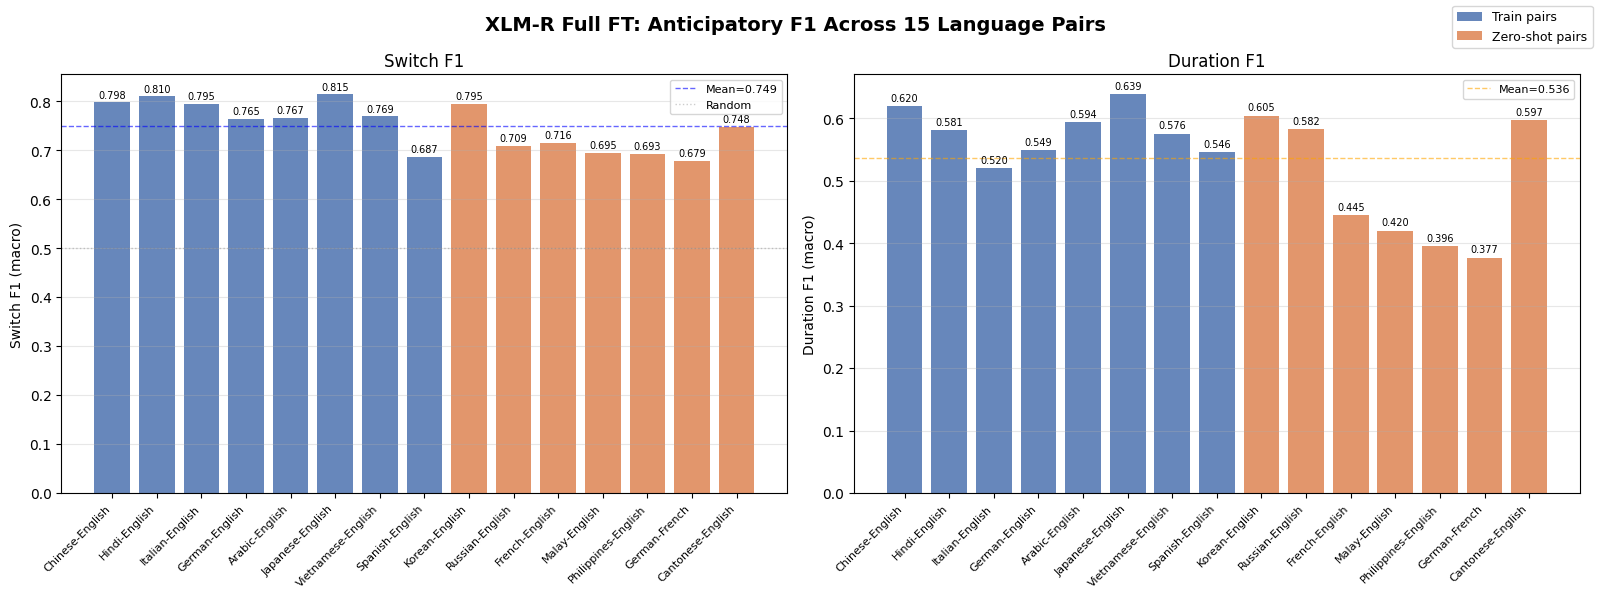


✓ XLM-R Final pipeline complete!
  σ_universality (Switch, all 15):   0.0471
  σ_universality (Duration, all 15): 0.0827


In [ ]:
# Cell 14: Visualization — Universality bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XLM-R Full FT: Anticipatory F1 Across 15 Language Pairs',
             fontsize=14, fontweight='bold')

# Prepare data in order: train pairs first, then zero-shot
pair_names = list(train_results.keys()) + list(zeroshot_results.keys())
sw_vals    = [all_results[p]['switch_f1'] for p in pair_names]
dur_vals   = [all_results[p]['duration_f1'] for p in pair_names]
colors     = ['#4C72B0'] * len(train_results) + ['#DD8452'] * len(zeroshot_results)

x = np.arange(len(pair_names))

# Switch F1
ax = axes[0]
bars = ax.bar(x, sw_vals, color=colors, alpha=0.85)
ax.axhline(np.mean(all_sw), color='blue', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Mean={np.mean(all_sw):.3f}')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, alpha=0.4, label='Random')
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Switch F1 (macro)')
ax.set_title('Switch F1')
ax.set_xticks(x)
ax.set_xticklabels(pair_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Duration F1
ax = axes[1]
bars = ax.bar(x, dur_vals, color=colors, alpha=0.85)
ax.axhline(np.mean(all_dur), color='orange', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Mean={np.mean(all_dur):.3f}')
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Duration F1 (macro)')
ax.set_title('Duration F1')
ax.set_xticks(x)
ax.set_xticklabels(pair_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', alpha=0.85, label='Train pairs'),
                   Patch(facecolor='#DD8452', alpha=0.85, label='Zero-shot pairs')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/xlmr_final_universality.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ XLM-R Final pipeline complete!")
print(f"  σ_universality (Switch, all 15):   {np.std(all_sw):.4f}")
print(f"  σ_universality (Duration, all 15): {np.std(all_dur):.4f}")

In [ ]:
# Cell 15: Persist artifacts summary (Kaggle addition)
import json, os

# Save training history as JSON
history_path = '/kaggle/working/xlmr_history.json'
with open(history_path, 'w') as f:
    # Convert any non-serializable values
    clean = []
    for h in xlmr_history:
        clean_h = {k: (v if not isinstance(v, dict) else
                       {kk: float(vv) for kk, vv in v.items()})
                   for k, v in h.items()}
        clean.append(clean_h)
    json.dump(clean, f, indent=2, default=float)
print(f"✓ History saved: {history_path}")

# Save final metrics + σ summary
summary = {
    'model': 'xlm-roberta-base',
    'mode':  'causal_full_fine_tuning',
    'train_pairs': [f"{a}-{b}" for a, b in TRAIN_PAIRS],
    'zeroshot_pairs': [f"{a}-{b}" for a, b in ZEROSHOT_PAIRS],
    'hyperparams': {
        'MAX_LEN':    MAX_LEN,
        'BATCH_SIZE': BATCH_SIZE,
        'NUM_EPOCHS': NUM_EPOCHS,
        'BASE_LR':    BASE_LR,
        'HEAD_LR':    HEAD_LR,
        'WARMUP_RATIO': WARMUP_RATIO,
    },
    'final_switch_f1':   float(xlmr_final['switch_f1']),
    'final_duration_f1': float(xlmr_final['duration_f1']),
    'n_epochs_run':      len(xlmr_history),
}
summary_path = '/kaggle/working/xlmr_final_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Summary saved: {summary_path}")

# List all artifacts
print("\n=== Files in /kaggle/working/ (will persist as notebook Output) ===")
for fname in sorted(os.listdir('/kaggle/working/')):
    fpath = os.path.join('/kaggle/working/', fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024**2
        print(f"  {fname:<45} {size_mb:>8.2f} MB")


✓ History saved: /kaggle/working/xlmr_history.json
✓ Summary saved: /kaggle/working/xlmr_final_summary.json

=== Files in /kaggle/working/ (will persist as notebook Output) ===
  __notebook__.ipynb                                3.96 MB
  best_xlmr_causal_final.pt                      1063.00 MB
  ckpt_latest.pt                                 3189.00 MB
  xlmr_final_summary.json                           0.00 MB
  xlmr_final_universality.png                       0.15 MB
  xlmr_history.json                                 0.01 MB
